# Wine Quality EDA

**Dataset:** UCI Wine Quality (Vinho Verde) — red + white combined  
**Shape:** 6,497 rows × 13 columns  
**Goal:** Explore the biochemical features that influence wine quality scores.

### 1. Data Loading
- Loaded `winequality-red.csv` and `winequality-white.csv` with `sep=';'`
- Added a `type` column (`'red'` / `'white'`) to each before combining
- Merged with `pd.concat()` and reset the index

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

red_wine = pd.read_csv('/Users/meschacolongo/Wine-quality/data/winequality-red.csv', sep=';')
white_wine = pd.read_csv('/Users/meschacolongo/Wine-quality/data/winequality-white.csv', sep=';')

red_wine['type'] = 'red'
white_wine['type'] = 'white'

df = pd.concat([red_wine, white_wine], ignore_index=True)

print(df.shape)
df.head()

(6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


### 2. Missing Value Check
- `df.isnull().sum()` confirmed **zero null values** across all columns

In [23]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

### 3. Descriptive Statistics
- `df.describe()` revealed notable outliers:
  - `residual sugar`: max = 65.8
  - `free sulfur dioxide`: max = 289
  - `chlorides`: max = 0.611

In [24]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


### 4. Outlier Detection
- Built `detect_outliers_iqr()` using the IQR method to flag outliers per column

In [25]:
def detect_outliers_iqr(df):
    numeric_cols = df.select_dtypes(include='number').columns
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]  # filter rows outside fences
        print(f"{col}: {len(outliers)} outliers")

detect_outliers_iqr(df)

fixed acidity: 357 outliers
volatile acidity: 377 outliers
citric acid: 509 outliers
residual sugar: 118 outliers
chlorides: 286 outliers
free sulfur dioxide: 62 outliers
total sulfur dioxide: 10 outliers
density: 3 outliers
pH: 73 outliers
sulphates: 191 outliers
alcohol: 3 outliers
quality: 228 outliers


### 5. Outlier Capping
- Built `cap_outliers_iqr()` using `.clip()` to cap at IQR-defined bounds
- `quality` was intentionally excluded from capping (it is the target variable)
- Result stored in `df_clean`

In [26]:
def cap_outliers_iqr(df):
    numeric_cols = df.select_dtypes(include='number').columns
    cols_to_cap = [col for col in numeric_cols if col != 'quality']  # exclude target variable
    df_capped = df.copy()
    for col in cols_to_cap:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_capped[col] = df_capped[col].clip(lower, upper)
    return df_capped

df_clean = cap_outliers_iqr(df)
print(df_clean.shape)

(6497, 13)


### 6. Verification
- Confirmed capping worked:
  - `residual sugar`: 65.8 → 17.55
  - `free sulfur dioxide`: 289 → 77.0
  - `chlorides`: 0.611 → 0.1055

In [27]:
print("Before capping:")
print(df[['residual sugar', 'free sulfur dioxide', 'chlorides']].describe().loc[['max']])

print("\nAfter capping:")
print(df_clean[['residual sugar', 'free sulfur dioxide', 'chlorides']].describe().loc[['max']])

Before capping:
     residual sugar  free sulfur dioxide  chlorides
max            65.8                289.0      0.611

After capping:
     residual sugar  free sulfur dioxide  chlorides
max           17.55                 77.0     0.1055


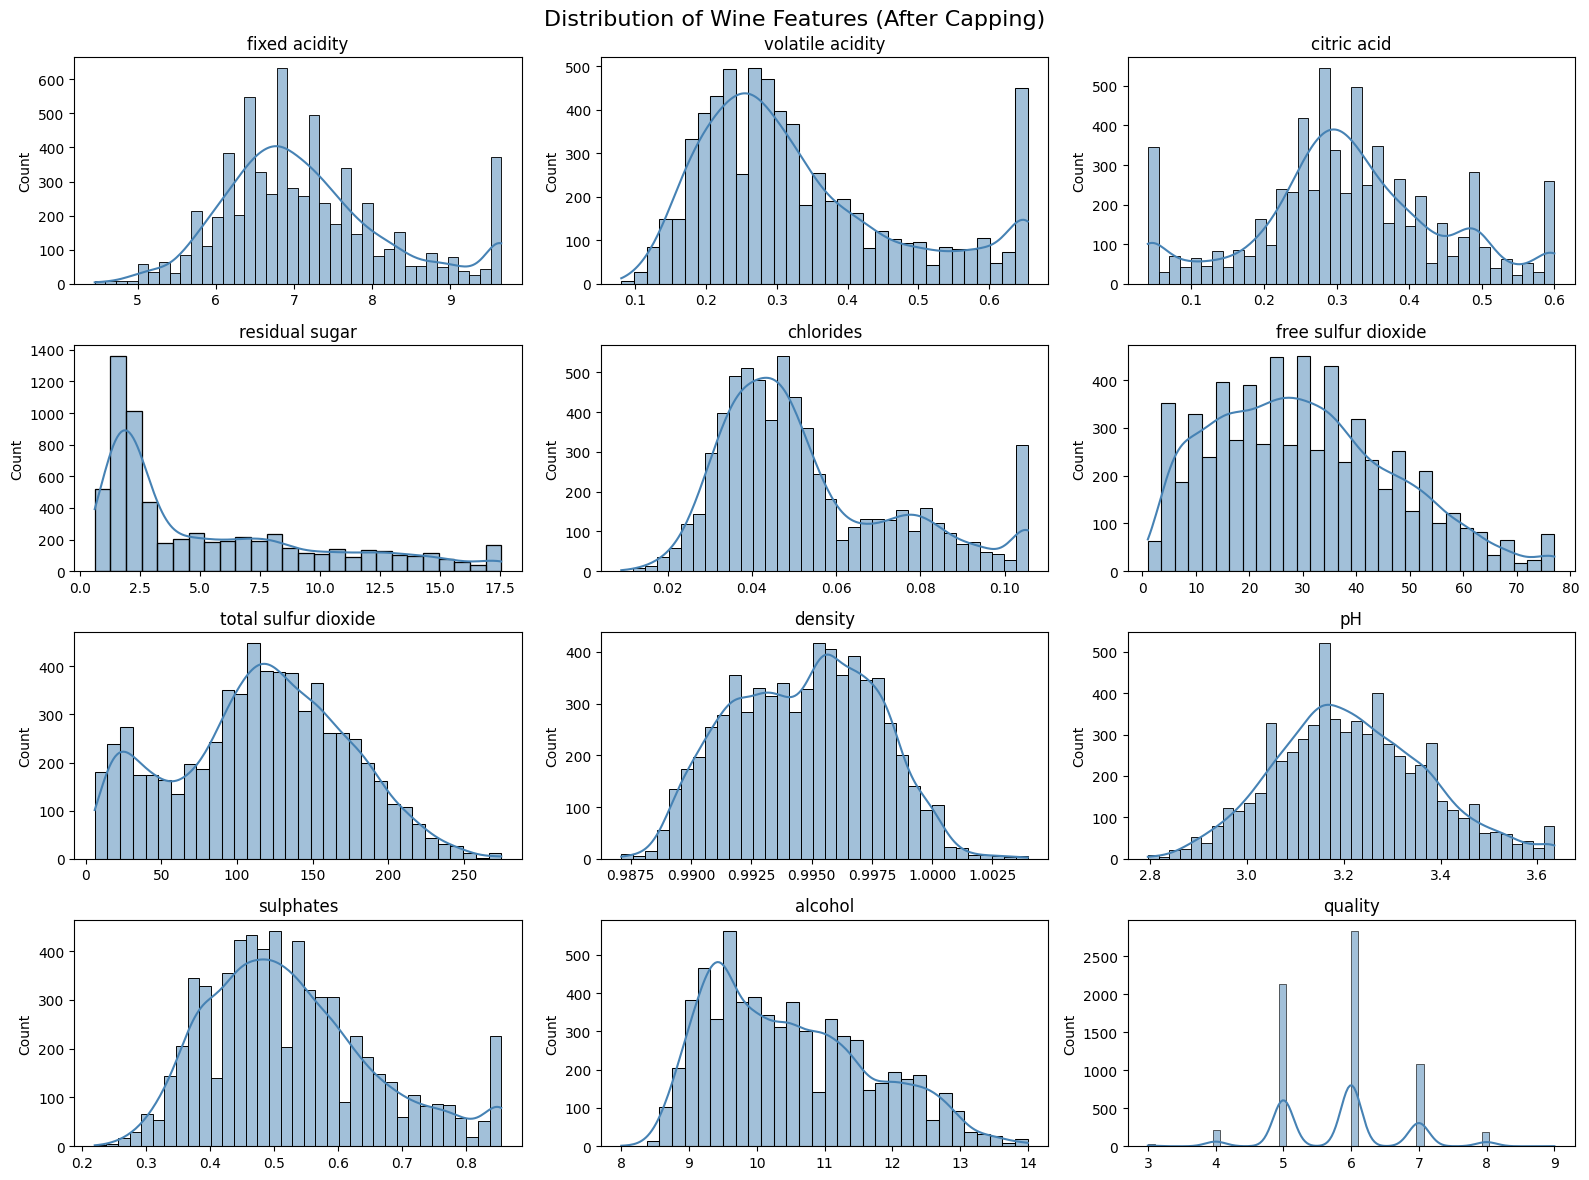

In [44]:
numeric_cols = df_clean.select_dtypes(include='number').columns

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df_clean[col], ax=axes[i], kde=True, color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Wine Features (After Capping)', fontsize=16)
plt.tight_layout()
plt.savefig('/Users/meschacolongo/Wine-quality/images/distribution_after_capping.png')
plt.show()

### Distributions

Histograms with KDE were plotted for all numeric features after outlier capping.
Most features show a right-skewed distribution, meaning the bulk of wines cluster
at lower values with a few high-value wines pulling the tail. Residual sugar is
notably skewed, suggesting most wines are dry with few sweet outliers. Quality
scores are roughly symmetric, with the majority of wines rated between 5 and 7.

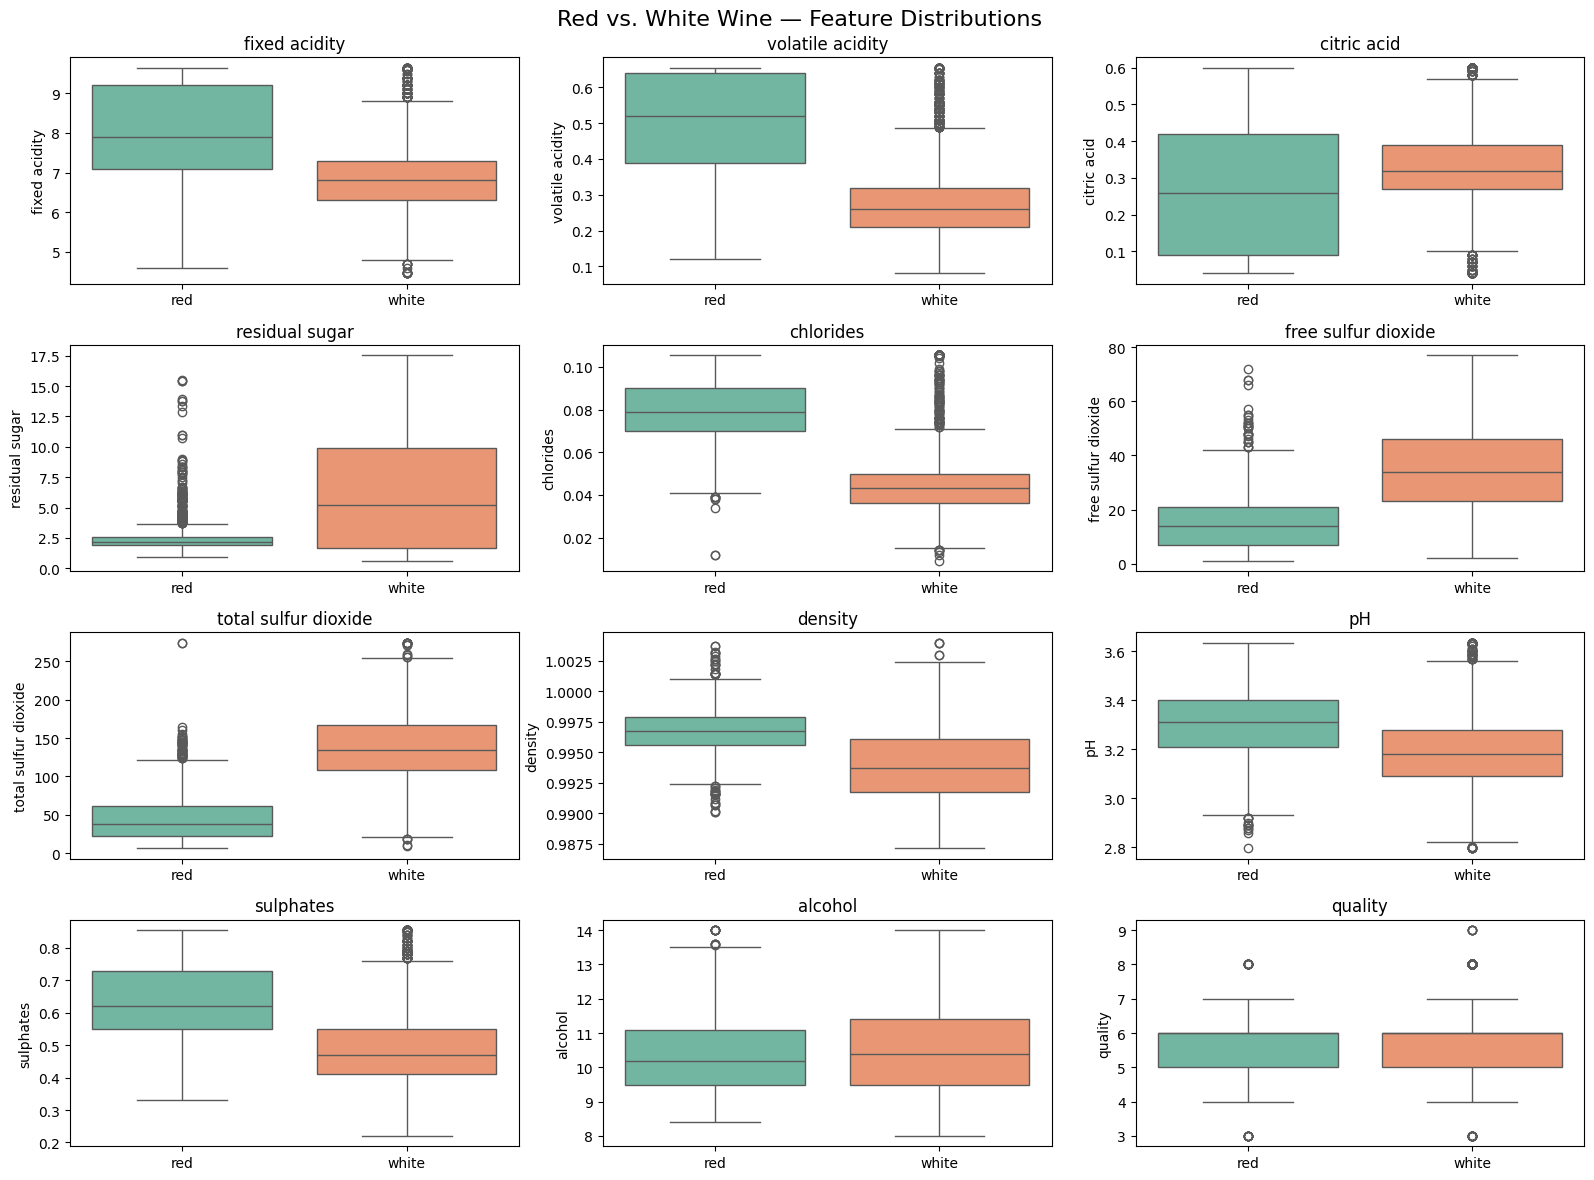

In [37]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df_clean, x='type', y=col, ax=axes[i], palette='Set2', hue='type', legend=False)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Red vs. White Wine — Feature Distributions', fontsize=16)
plt.tight_layout()
plt.savefig('/Users/meschacolongo/Wine-quality/images/red_vs_white_boxplots.png')
plt.show()

### Red vs. White Wine Comparisons

Grouped boxplots revealed clear chemical differences between red and white wines.
White wines showed significantly higher residual sugar and total sulfur dioxide,
reflecting their sweeter style and greater need for SO₂ as a preservative in the
absence of tannins. Red wines had notably higher volatile acidity, consistent with
greater bacterial activity during fermentation.

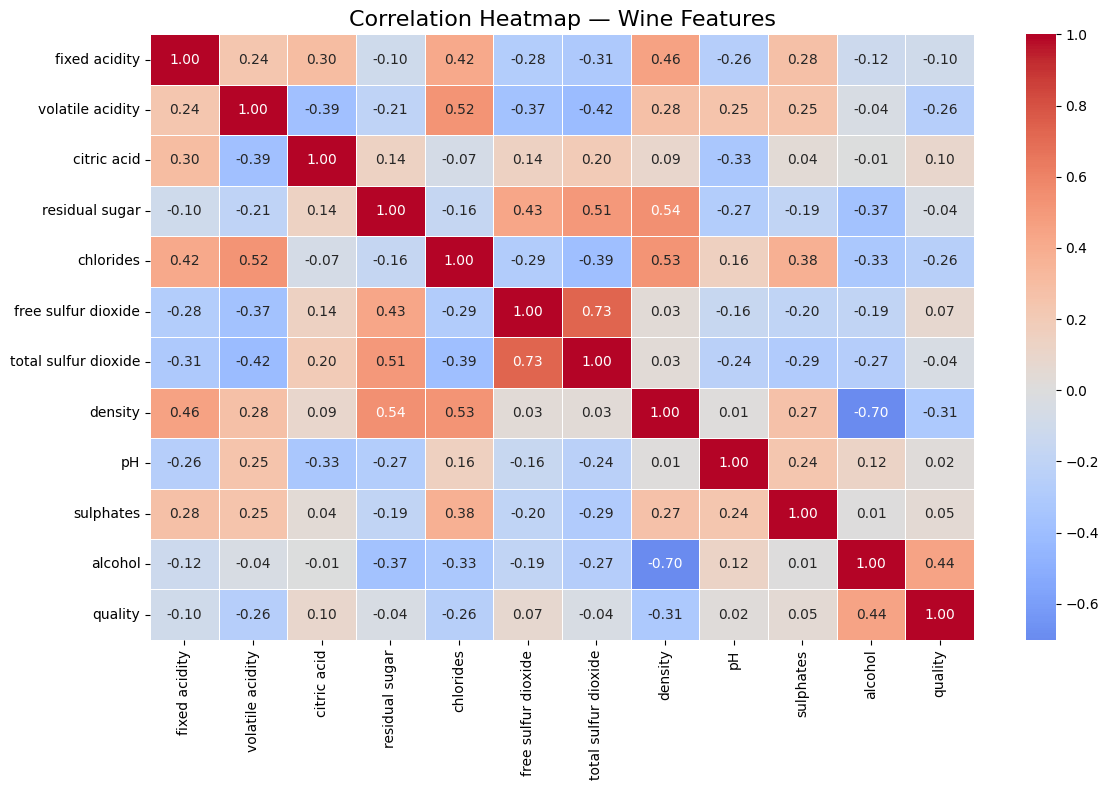

In [38]:
plt.figure(figsize=(12, 8))

correlation_matrix = df_clean.select_dtypes(include='number').corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)

plt.title('Correlation Heatmap — Wine Features', fontsize=16)
plt.tight_layout()
plt.savefig('/Users/meschacolongo/Wine-quality/images/correlation_heatmap.png')
plt.show()

### Correlation Heatmap

A heatmap of Pearson correlations revealed that alcohol has the strongest positive
correlation with quality (0.44), while density has the strongest negative correlation
(-0.31). Among non-quality pairs, alcohol and density show a strong negative
correlation (-0.70), which reflects the physical fact that alcohol is less dense
than water. Residual sugar and density are also positively correlated (0.54),
consistent with sugar increasing the density of the solution.

## Conclusion

This EDA explored the biochemical composition of 6,497 red and white Vinho Verde
wines. After capping outliers in residual sugar, free sulfur dioxide, and chlorides,
three main findings emerged:

- **Wine type drives chemistry:** white wines have significantly higher residual
  sugar and total sulfur dioxide, while red wines have higher volatile acidity —
  all consistent with known winemaking practices.
- **Alcohol is the strongest predictor of quality:** with a correlation of 0.44,
  higher alcohol content is associated with better quality scores.
- **Density reflects physical composition:** strongly negatively correlated with
  alcohol (-0.70) and positively with residual sugar (0.54), density acts as a
  summary variable of the wine's dissolved content.

Quality scores were concentrated between 5 and 7, suggesting the dataset contains
few exceptional or very poor wines, which may limit predictive modeling in later stages.